In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-chech')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from global_ppo_3gnb_env import GlobalPPO3GNBEnv

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready')

Ready


In [2]:
SCENARIO = 'mixed_overlap_with_fixed_slice_loads'
N_PRBS   = 100          # physical PRBs per gNB (default)
N_SAMPLES = 300         # local scheduler ticks to record
SAMPLE_EVERY = 1        # record every tick
SLICE_COLORS = {'eMBB': '#f4a261', 'URLLC': '#e63946', 'mMTC': '#6a4c93'}
GNB_LINESTYLES = ['-', '--', ':']
GNB_COLORS = ['steelblue', 'tomato', 'seagreen']

# radio_substeps * radio_tick_seconds == upper_window_seconds / local_steps_per_global
# 10 * 0.01 = 0.1 = 1.0 / 10
env = GlobalPPO3GNBEnv(
    seed=42,
    scenario_mode='curriculum',
    training_scenarios=SCENARIO,
    scenario_selection='cycle',
    upper_window_seconds=1.0,
    local_steps_per_global=10,
    radio_substeps=10,
    radio_tick_seconds=0.01,
    pf_averaging_window_s=0.25,
    terminal_reward_only=False,
    safe_admission_enabled=True,
)
env.reset(seed=42)

# Neutral bias: retain all UEs on their initial gNB
env._apply_slice_offsets(np.full((3, 2, 3), 6.0, dtype=float))
env.base_env.begin_safe_admission_window(
    np.zeros((3, 2, 3), dtype=np.float32), env.slice_types
)

ues = sorted(env.base_env.get_all_ues(), key=lambda u: int(u.id))
slice_types = list(env.slice_types)
n_prbs = int(env.base_env.gnbs[0].n_prbs)

print(f'Scenario : {SCENARIO}')
print(f'UEs      : {len(ues)}')
print(f'n_prbs   : {n_prbs}')
print(f'Slices   : {slice_types}')
print()
ue_df = pd.DataFrame([
    dict(id=int(u.id), x=round(float(u.x),1), y=round(float(u.y),1),
         slice=u.slice_type, gNB=int(u.serving_gnb))
    for u in ues
])
display(ue_df)

Scenario : mixed_overlap_with_fixed_slice_loads
UEs      : 12
n_prbs   : 100
Slices   : ['eMBB', 'URLLC', 'mMTC']



,id,x,y,slice,gNB
0,0,-165.0,-30.0,eMBB,1
1,1,165.0,-30.0,eMBB,1
2,2,-165.0,30.0,eMBB,1
3,3,165.0,30.0,eMBB,1
4,4,-165.0,-15.0,URLLC,1
5,5,165.0,-15.0,URLLC,1
6,6,-165.0,45.0,URLLC,1
7,7,165.0,45.0,URLLC,1
8,8,-570.0,-35.0,mMTC,0
9,9,-570.0,35.0,mMTC,0


In [3]:
records = []
for tick in range(N_SAMPLES):
    env.base_env.step(0)
    if tick % SAMPLE_EVERY == 0:
        row = {'tick': tick}
        for gnb_id in range(3):
            for sl in slice_types:
                load = float(env.base_env.estimate_slice_load(gnb_id, sl))
                row[f'gNB{gnb_id}_{sl}_prbs'] = load * n_prbs
            # per-UE useful PRBs
        for u in ues:
            row[f'UE{int(u.id)}_useful_prbs'] = int(getattr(u, 'useful_prbs', 0))
        records.append(row)

df = pd.DataFrame(records)
print(f'Collected {len(df)} samples')
df.tail(3)

Collected 300 samples


,tick,gNB0_eMBB_prbs,gNB0_URLLC_prbs,gNB0_mMTC_prbs,gNB1_eMBB_prbs,gNB1_URLLC_prbs,gNB1_mMTC_prbs,gNB2_eMBB_prbs,gNB2_URLLC_prbs,gNB2_mMTC_prbs,...,UE2_useful_prbs,UE3_useful_prbs,UE4_useful_prbs,UE5_useful_prbs,UE6_useful_prbs,UE7_useful_prbs,UE8_useful_prbs,UE9_useful_prbs,UE10_useful_prbs,UE11_useful_prbs
297,297,0.0,0.0,36.0,64.0,36.0,0.0,0.0,32.0,0.0,...,16,16,12,6,4,14,18,17,16,16
298,298,0.0,0.0,38.0,64.0,36.0,0.0,0.0,32.0,0.0,...,16,16,12,10,0,14,18,19,16,16
299,299,0.0,0.0,36.0,58.0,42.0,0.0,0.0,36.0,0.0,...,14,14,12,10,6,14,17,17,17,17


## Per-gNB useful PRBs by slice — time series

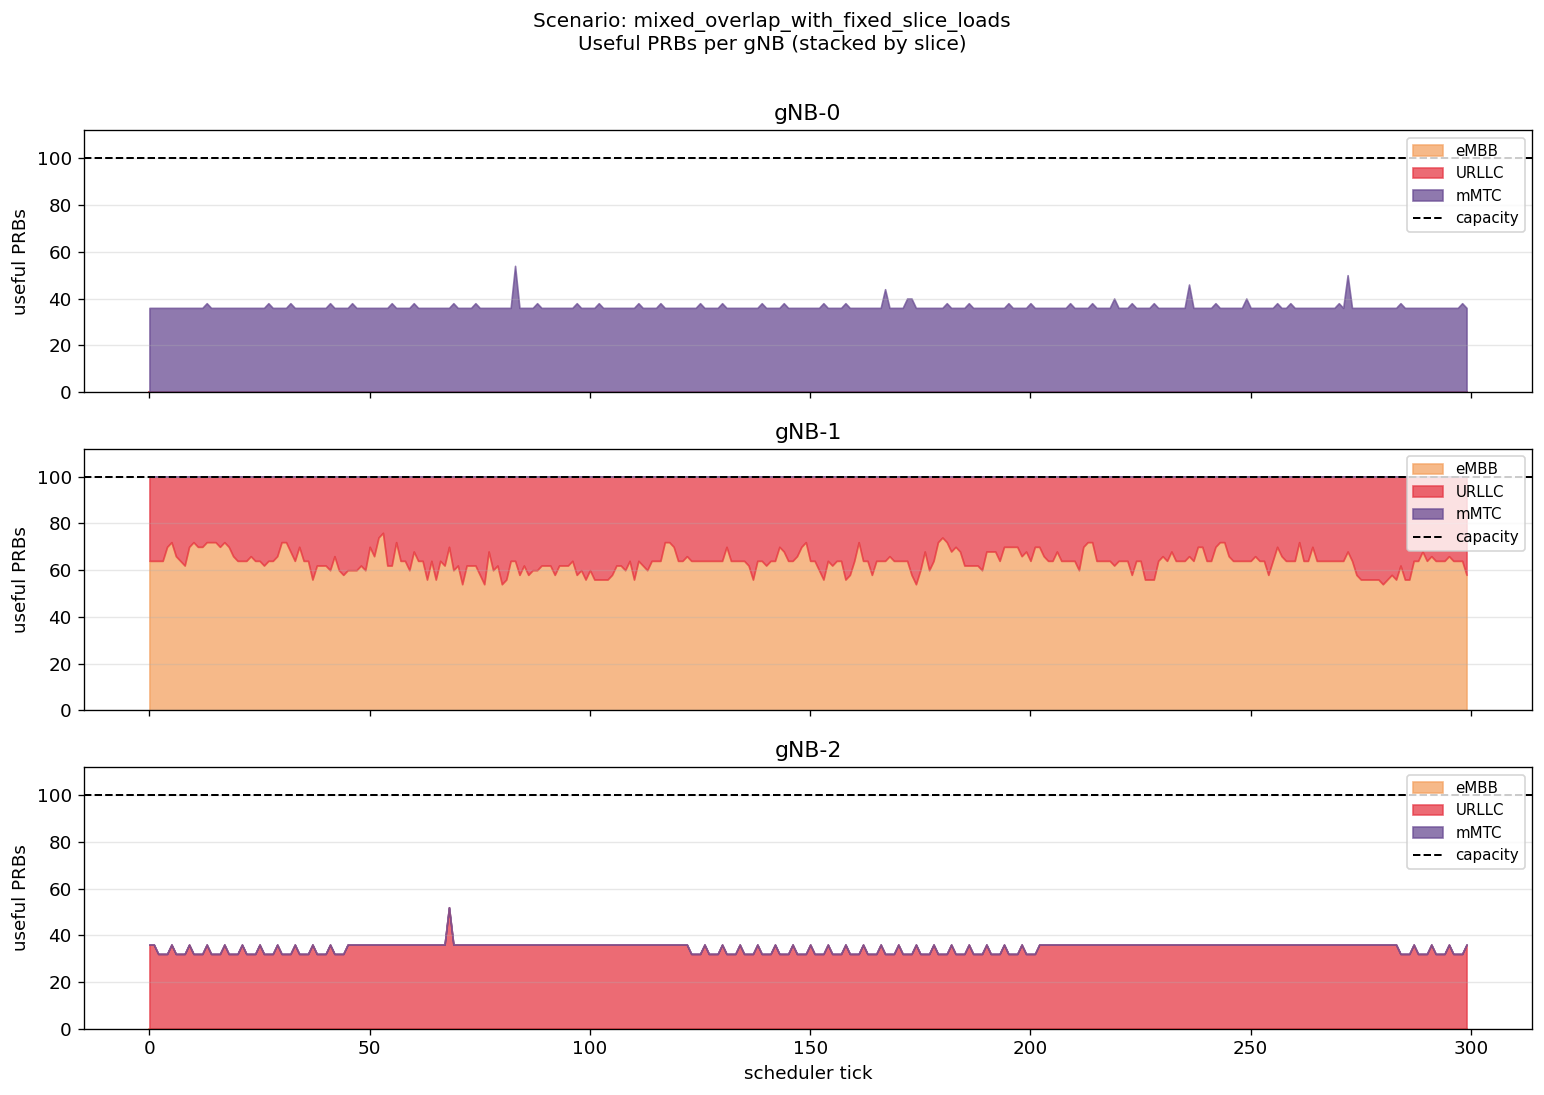

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, gnb_id in zip(axes, range(3)):
    bottom = np.zeros(len(df))
    for sl in slice_types:
        col = f'gNB{gnb_id}_{sl}_prbs'
        values = df[col].values
        ax.fill_between(df['tick'], bottom, bottom + values,
                        alpha=0.75, label=sl, color=SLICE_COLORS[sl])
        bottom = bottom + values
    ax.axhline(n_prbs, color='black', linestyle='--', lw=1.2, label='capacity')
    ax.set_ylim(0, n_prbs * 1.12)
    ax.set_ylabel('useful PRBs')
    ax.set_title(f'gNB-{gnb_id}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('scheduler tick')
fig.suptitle(
    f'Scenario: {SCENARIO}\nUseful PRBs per gNB (stacked by slice)',
    y=1.01, fontsize=12
)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'scenario_plots' / 'mixed_overlap_useful_prb_timeseries.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Mean useful PRBs — stacked bar summary

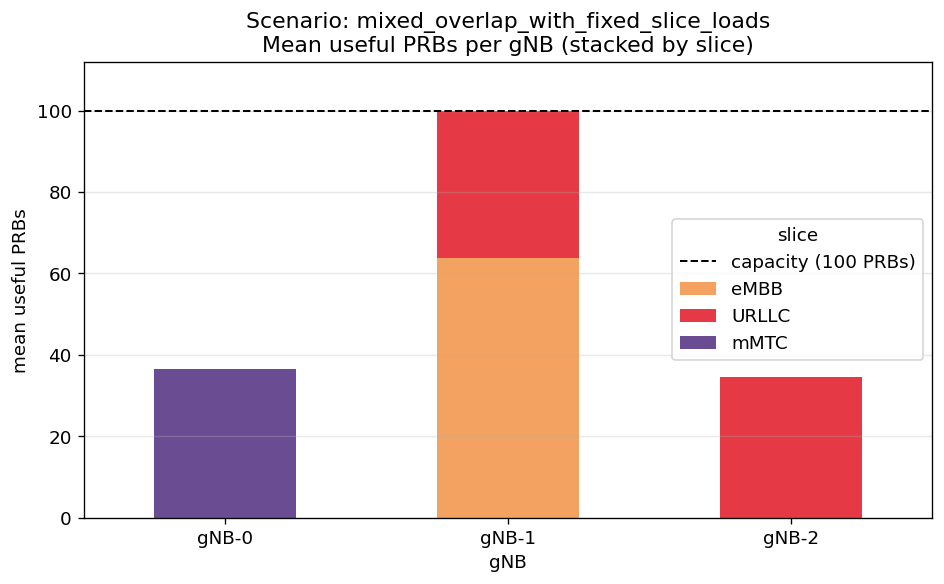


Mean useful PRBs summary:


,eMBB,URLLC,mMTC,total,utilization_%
gNB-0,0.0,0.0,36.4,36.4,36.4
gNB-1,63.9,36.1,0.0,100.0,100.0
gNB-2,0.0,34.7,0.0,34.7,34.7


In [5]:
mean_data = pd.DataFrame(
    {sl: [df[f'gNB{g}_{sl}_prbs'].mean() for g in range(3)] for sl in slice_types},
    index=[f'gNB-{g}' for g in range(3)],
)

fig, ax = plt.subplots(figsize=(8, 5))
mean_data.plot(
    kind='bar', stacked=True, ax=ax,
    color=[SLICE_COLORS[s] for s in slice_types],
)
ax.axhline(n_prbs, color='black', linestyle='--', lw=1.2, label=f'capacity ({n_prbs} PRBs)')
ax.set_ylim(0, n_prbs * 1.12)
ax.set_ylabel('mean useful PRBs')
ax.set_xlabel('gNB')
ax.set_title(f'Scenario: {SCENARIO}\nMean useful PRBs per gNB (stacked by slice)')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='slice')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'scenario_plots' / 'mixed_overlap_useful_prb_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nMean useful PRBs summary:')
mean_data['total'] = mean_data.sum(axis=1)
mean_data['utilization_%'] = 100.0 * mean_data['total'] / n_prbs
display(mean_data.style.format('{:.1f}'))

## Per-UE useful PRBs — individual traces

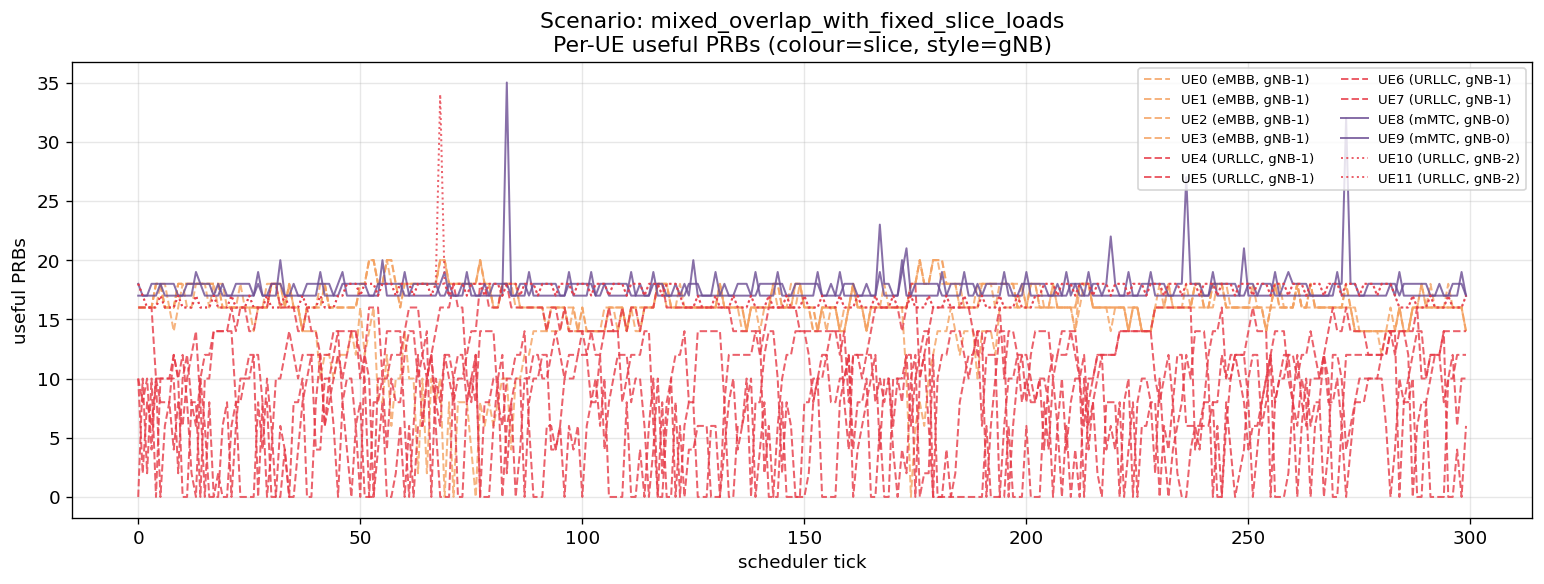

In [6]:
ue_cols = [f'UE{int(u.id)}_useful_prbs' for u in ues]
ue_labels = [
    f'UE{int(u.id)} ({u.slice_type}, gNB-{int(u.serving_gnb)})'
    for u in ues
]

fig, ax = plt.subplots(figsize=(13, 5))
for col, label, u in zip(ue_cols, ue_labels, ues):
    color = SLICE_COLORS[u.slice_type]
    gnb_ls = GNB_LINESTYLES[int(u.serving_gnb) % 3]
    ax.plot(df['tick'], df[col], lw=1.2, ls=gnb_ls, color=color, label=label, alpha=0.8)

ax.set_xlabel('scheduler tick')
ax.set_ylabel('useful PRBs')
ax.set_title(f'Scenario: {SCENARIO}\nPer-UE useful PRBs (colour=slice, style=gNB)')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'scenario_plots' / 'mixed_overlap_useful_prb_per_ue.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
env.close()
print('Done.')

Done.
